In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

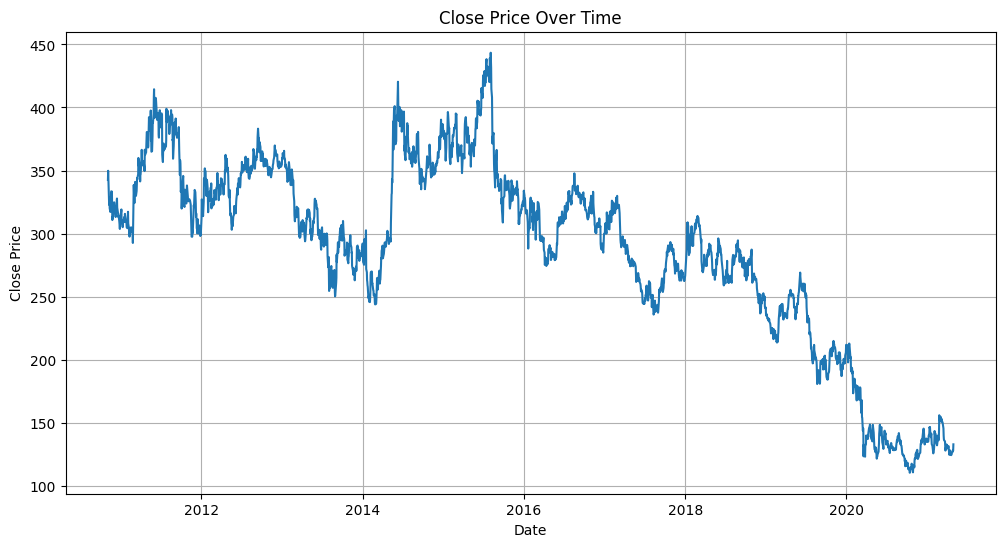

In [14]:
# Load the ADANIPORTS.csv file
df = pd.read_csv('./Data/COALINDIA.csv')


df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the new index
df.set_index('Date', inplace=True) 

plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [5]:
df.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [15]:
import pandas as pd

window = 252  # 1 trading year

def rolling_normalize(df):
    df = df.sort_values('Date')
    df['close_mean'] = df['Close'].rolling(window).mean()
    df['close_std'] = df['Close'].rolling(window).std()
    df['close_z'] = (df['Close'] - df['close_mean']) / df['close_std']
    return df

data = df.groupby('Symbol', group_keys=False).apply(rolling_normalize)


C:\Users\Dhile\AppData\Local\Temp\ipykernel_21736\2002393039.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = df.groupby('Symbol', group_keys=False).apply(rolling_normalize)


In [16]:
data.dropna(inplace=True)

In [17]:
data

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,close_mean,close_std,close_z
Date,,,,,,,,,,,,,,,,,
2011-11-09,COALINDIA,EQ,327.30,329.00,330.30,324.55,324.95,326.10,327.98,3703073,1.214526e+14,58108.0,2676954,0.7229,350.501786,32.465819,-0.751615
2011-11-11,COALINDIA,EQ,326.10,325.00,328.45,323.80,325.30,326.10,326.70,4015218,1.311781e+14,56873.0,2908994,0.7245,350.436508,32.498392,-0.748853
2011-11-14,COALINDIA,EQ,326.10,326.10,326.90,319.40,323.30,323.10,323.11,2911632,9.407809e+13,36876.0,1555907,0.5344,350.330357,32.543971,-0.836725
2011-11-15,COALINDIA,EQ,323.10,322.00,325.40,314.90,316.00,317.15,322.36,2426013,7.820496e+13,31937.0,1602035,0.6604,350.276389,32.587818,-1.016527
2011-11-16,COALINDIA,EQ,317.15,316.90,317.25,306.05,311.90,311.65,310.73,3890690,1.208938e+14,71228.0,2323491,0.5972,350.219246,32.643046,-1.181546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-26,COALINDIA,EQ,126.15,127.75,128.00,126.50,127.00,126.95,127.30,4967884,6.324104e+13,29393.0,1755583,0.3534,132.037302,9.571509,-0.531505
2021-04-27,COALINDIA,EQ,126.95,127.00,127.90,126.60,127.55,127.50,127.47,3982954,5.077023e+13,28486.0,1521312,0.3820,131.984127,9.559290,-0.469086
2021-04-28,COALINDIA,EQ,127.50,128.00,129.45,127.50,128.50,128.50,128.67,6206074,7.985049e+13,32352.0,1981995,0.3194,131.950397,9.556517,-0.361052


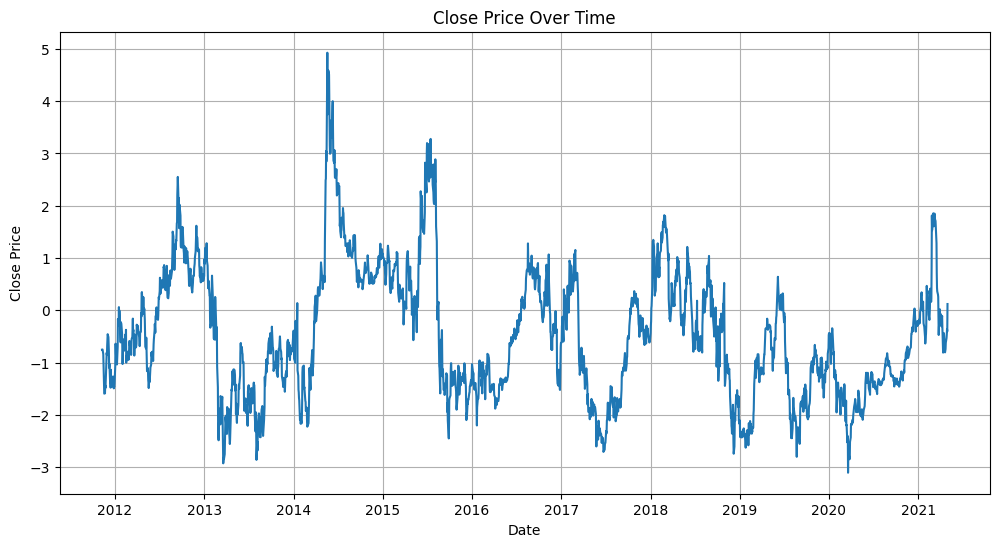

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(data['close_z'])
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [25]:
import pandas as pd
import numpy as np

# 1. Define the start and end dates
start_date = '2010-01-01'
end_date = '2020-12-31' # We use the end of 2020 to cover the years from 2010 to 2020 inclusive

# 2. Generate the date range with daily frequency ('D')
# This creates a DatetimeIndex covering the period
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# The number of dates generated is 4018, not 2521. 
# We need to adjust the frequency to match the required number of values (0 to 2520, which is 2521 values total).

# Let's recalculate the date range using the required number of periods
num_periods = 3600
date_range_adjusted = pd.date_range(start=start_date, periods=num_periods, freq='D') # Use start date and number of periods

# 3. Create the list of values from 0 to 2520 (inclusive)
values = np.arange(0, num_periods)

# 4. Create the DataFrame
df = pd.DataFrame({'Close': values}, index=date_range_adjusted)
df["Symbol"] = "TEST"
df.index.name = 'Date'

# Print the DataFrame info and first/last few rows to verify
print(df.info())
print(df.head())
print(df.tail())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3600 entries, 2010-01-01 to 2019-11-09
Freq: D
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Close   3600 non-null   int32 
 1   Symbol  3600 non-null   object
dtypes: int32(1), object(1)
memory usage: 70.3+ KB
None
            Close Symbol
Date                    
2010-01-01      0   TEST
2010-01-02      1   TEST
2010-01-03      2   TEST
2010-01-04      3   TEST
2010-01-05      4   TEST
            Close Symbol
Date                    
2019-11-05   3595   TEST
2019-11-06   3596   TEST
2019-11-07   3597   TEST
2019-11-08   3598   TEST
2019-11-09   3599   TEST


In [ ]:
import pandas as pd

window = 252  # 1 trading year

def rolling_normalize(df):
    df = df.sort_values('Date')
    df['close_mean'] = df['Close'].rolling(window).mean()
    df['close_std'] = df['Close'].rolling(window).std()
    df['close_z'] = (df['Close'] - df['close_mean']) / df['close_std']
    return df

data = df.groupby('Symbol', group_keys=False).apply(rolling_normalize)


C:\Users\Dhile\AppData\Local\Temp\ipykernel_21736\2431388402.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = df.groupby('Symbol', group_keys=False).apply(rolling_normalize)


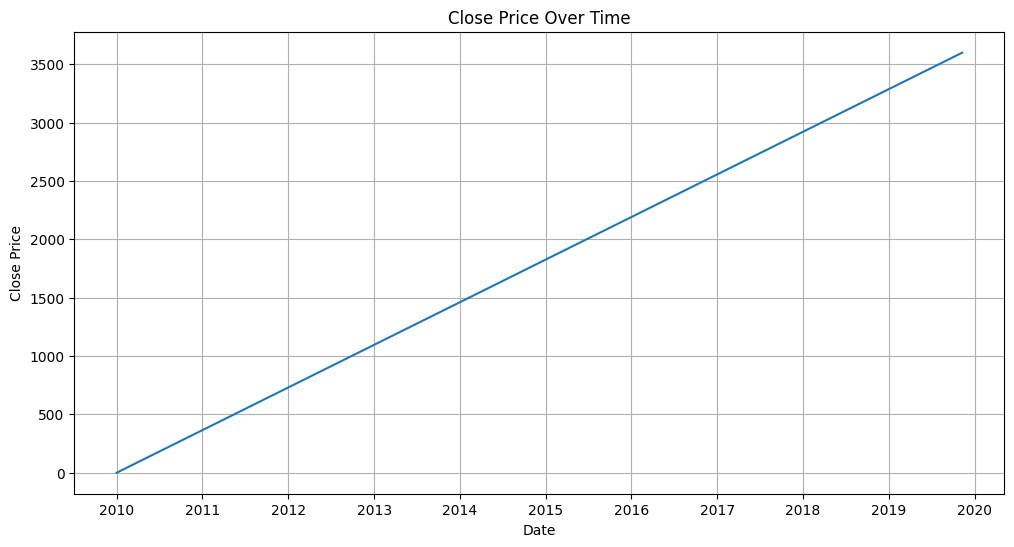

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

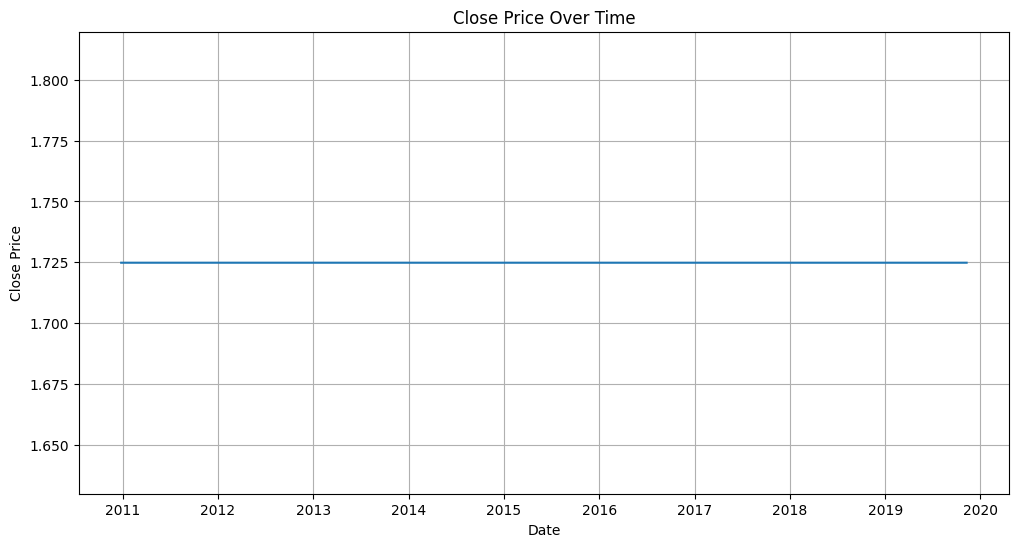

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(data['close_z'])
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [5]:
import pandas as pd

# assume df is your DataFrame
df = df.copy()
df.index = pd.to_datetime(df.index)

# define ex-split date and split ratio
split_date = pd.Timestamp("2017-01-04")
split_ratio = 10  # 10-for-1 split

# identify rows before the split
mask = df.index < split_date

# price columns — divide by split ratio
price_cols = ["Prev Close", "Open", "High", "Low", "Last", "Close", "VWAP"]
df.loc[mask, price_cols] = df.loc[mask, price_cols] / split_ratio

# volume columns — multiply by split ratio
volume_cols = ["Volume", "Turnover", "Deliverable Volume"]
df.loc[mask, volume_cols] = df.loc[mask, volume_cols] * split_ratio

# %Deliverble and Trades remain unchanged
print("✅ Stock split adjustment complete for data before", split_date.date())


✅ Stock split adjustment complete for data before 2017-01-04


In [7]:
df

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2005-03-23,JSWSTL,EQ,1.000,45.500,45.850,38.360,38.69,39.015,41.986,20877100,8.765375e+14,NaN,3820570,0.1830
2005-03-24,JSWSTL,EQ,39.015,39.285,39.850,35.750,37.18,36.920,37.201,12264790,4.562638e+14,NaN,2321720,0.1893
2005-03-28,JSWSTL,EQ,36.920,37.670,39.405,37.500,38.00,37.885,38.364,12357940,4.741048e+14,NaN,2634150,0.2132
2005-03-29,JSWSTL,EQ,37.885,38.290,38.380,36.325,36.91,36.805,37.526,6240720,2.341915e+14,NaN,1989160,0.3187
2005-03-30,JSWSTL,EQ,36.805,36.700,37.190,36.005,36.27,36.215,36.513,4663490,1.702775e+14,NaN,1596410,0.3423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-26,JSWSTEEL,EQ,635.400,642.000,660.700,638.250,657.00,655.800,651.460,16506538,1.075335e+15,186271.0,1837617,0.1113
2021-04-27,JSWSTEEL,EQ,655.800,660.650,670.350,658.000,666.35,665.900,664.150,15799458,1.049323e+15,174214.0,1222165,0.0774
2021-04-28,JSWSTEEL,EQ,665.900,669.750,676.000,650.650,662.50,662.650,661.630,15558949,1.029430e+15,175365.0,2366037,0.1521


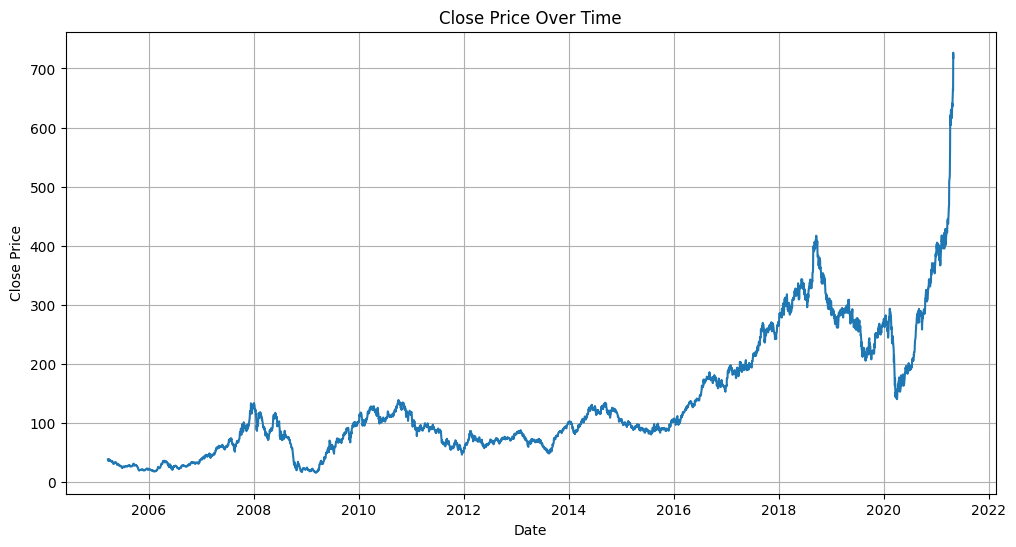

In [9]:

plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [5]:
offset = 5
df = df.sort_values(['Symbol','Date'])
df['forward_ret'] = df.groupby('Symbol')['Close'].shift(-offset) / df['Close'] - 1
# Optionally log-return:
df['forward_logret'] = np.log(df.groupby('Symbol')['Close'].shift(-offset)) - np.log(df['Close'])

In [6]:
df

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,forward_ret,forward_logret
Date,,,,,,,,,,,,,,,,
2012-01-17,ADANIPORTS,EQ,135.50,137.10,141.00,135.00,140.10,140.00,138.13,1636196,2.260074e+13,18374.0,1004327,0.6138,0.071786,0.069326
2012-01-18,ADANIPORTS,EQ,140.00,142.00,143.80,138.70,143.00,141.70,141.25,890591,1.257986e+13,15615.0,404925,0.4547,0.010586,0.010530
2012-01-19,ADANIPORTS,EQ,141.70,144.00,150.55,143.15,149.50,149.40,146.72,1456077,2.136382e+13,31299.0,721545,0.4955,-0.015395,-0.015515
2012-01-20,ADANIPORTS,EQ,149.40,151.90,157.60,150.25,155.40,155.40,153.76,1634070,2.512583e+13,23335.0,861145,0.5270,-0.109395,-0.115854
2012-01-23,ADANIPORTS,EQ,155.40,155.40,155.40,145.10,146.40,146.75,149.54,1657609,2.478768e+13,12400.0,820653,0.4951,-0.003407,-0.003413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-01-10,MUNDRAPORT,EQ,132.20,133.85,137.00,132.85,136.30,136.45,135.67,869679,1.179905e+13,13330.0,476412,0.5478,NaN,NaN
2012-01-11,MUNDRAPORT,EQ,136.45,136.00,140.70,134.75,135.75,137.05,137.28,1810746,2.485799e+13,16447.0,799955,0.4418,NaN,NaN
2012-01-12,MUNDRAPORT,EQ,137.05,137.50,137.50,131.20,131.60,132.65,133.23,1748799,2.329973e+13,10429.0,1029768,0.5888,NaN,NaN


In [7]:
def classify_return(x):
    if x < -2: return -1
    elif -2 <= x <= 2: return 0
    elif x > 2: return 1

In [ ]:
df['target'] = df['forward_ret'].apply(classify_return)

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,forward_ret,forward_logret,target
Date,,,,,,,,,,,,,,,,,
2012-01-17,ADANIPORTS,EQ,135.50,137.10,141.00,135.00,140.10,140.00,138.13,1636196,2.260074e+13,18374.0,1004327,0.6138,0.071786,0.069326,0.0
2012-01-18,ADANIPORTS,EQ,140.00,142.00,143.80,138.70,143.00,141.70,141.25,890591,1.257986e+13,15615.0,404925,0.4547,0.010586,0.010530,0.0
2012-01-19,ADANIPORTS,EQ,141.70,144.00,150.55,143.15,149.50,149.40,146.72,1456077,2.136382e+13,31299.0,721545,0.4955,-0.015395,-0.015515,0.0
2012-01-20,ADANIPORTS,EQ,149.40,151.90,157.60,150.25,155.40,155.40,153.76,1634070,2.512583e+13,23335.0,861145,0.5270,-0.109395,-0.115854,0.0
2012-01-23,ADANIPORTS,EQ,155.40,155.40,155.40,145.10,146.40,146.75,149.54,1657609,2.478768e+13,12400.0,820653,0.4951,-0.003407,-0.003413,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-01-10,MUNDRAPORT,EQ,132.20,133.85,137.00,132.85,136.30,136.45,135.67,869679,1.179905e+13,13330.0,476412,0.5478,NaN,NaN,NaN
2012-01-11,MUNDRAPORT,EQ,136.45,136.00,140.70,134.75,135.75,137.05,137.28,1810746,2.485799e+13,16447.0,799955,0.4418,NaN,NaN,NaN
2012-01-12,MUNDRAPORT,EQ,137.05,137.50,137.50,131.20,131.60,132.65,133.23,1748799,2.329973e+13,10429.0,1029768,0.5888,NaN,NaN,NaN


In [14]:
import yfinance as yf

# Define the ticker symbol
ticker = yf.Ticker("ADANIPORTS.NS") # Example: Apple Inc.

# Get historical data for a specific period (e.g., 1 month)
history = ticker.history(period="1mo")
print(history)

# Get data for a custom date range
# history_range = ticker.history(start="2019-05-31", end="2021-01-30")


YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [12]:
history

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


In [ ]:
# Standardize column names in test data
rename_map = {
    'series': 'Series',
    'OPEN': 'Open',
    'HIGH': 'High',
    'LOW': 'Low',
    'PREV. CLOSE': 'Prev Close',
    'ltp': 'Last',
    'close': 'Close',
    'vwap': 'VWAP',
    'VOLUME': 'Volume',
    'VALUE': 'Turnover',           # same meaning
    'No of trades': 'Trades',
    '52W H': '52W_H',
    '52W L': '52W_L'
}

df_test = df_test.rename(columns=rename_map)
